# Fase 1 — Reconocimiento de Patrones: Firmas Off-Line (Dataset Personal)

## Universidad Autónoma de Aguascalientes
## Ingeniería en Computación Inteligente — Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Guillermo González Lara (237864) — Semestre Enero–Junio 2026

---

**Descripción general**

Sistema completo de verificación de firmas off-line usando un dataset personal de cheques firmados.
Todas las imágenes son cheques completos; la firma siempre se localiza en la **esquina inferior derecha**.

```
dataset/
├── real/          ← 15 cheques con firma auténtica
├── fake/          ← 15 cheques con firma falsificada
├── real_test.jpg  ← cheque de prueba final (auténtico)
└── fake_test.jpg  ← cheque de prueba final (falsificado)
```

**Flujo completo:**
```
Cheque completo
      │
      ▼
 Pre-recorte región inferior derecha
 (FIRMA_X_PCT / FIRMA_Y_PCT / FIRMA_Y_FIN)
      │
      ▼
 Umbral adaptativo + morfología + componente mayor
      │
      ▼
 Firma binarizada normalizada (TARGET_H × TARGET_W)
      │
      ▼
 54 EE morfológicos → vector de 54 características
      │
      ▼
 BPNN · SVM · KNN · Naive Bayes
      │
      ▼
 Auténtica / Falsificación
```
---

## 0 · Dependencias

In [1]:
# !pip install opencv-python-headless numpy matplotlib scikit-image scikit-learn scipy tqdm -q

import os, glob, warnings, random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm
from scipy.ndimage import rotate as ndrotate
from skimage.morphology import binary_erosion

from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

print('✔  Dependencias cargadas correctamente.')

✔  Dependencias cargadas correctamente.


---
## Etapa 1 · Selección de Datos
### Adquisición de imágenes con firmas off-line

El conjunto de datos consiste en 15 fotografías de la firma auténtica del alumno y 15 fotografías de una firma falsificada, organizadas en las carpetas `/real` y `/fake`.

In [2]:
# ── Configuración de rutas ────────────────────────────────────────────────────
DATASET_ROOT = './content/sample_data/dataset'

REAL_DIR  = os.path.join(DATASET_ROOT, 'real')
FAKE_DIR  = os.path.join(DATASET_ROOT, 'fake')
TEST_REAL = os.path.join(DATASET_ROOT, 'real_test.jpg')
TEST_FAKE = os.path.join(DATASET_ROOT, 'fake_test.jpg')

IMG_EXTS = ('*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif', '*.tiff')

def load_paths(folder):
    paths = []
    for ext in IMG_EXTS:
        paths.extend(glob.glob(os.path.join(folder, ext)))
    return sorted(paths)

real_paths = load_paths(REAL_DIR)
fake_paths = load_paths(FAKE_DIR)

assert len(real_paths) > 0, f'No se encontraron imágenes en {REAL_DIR}'
assert len(fake_paths) > 0, f'No se encontraron imágenes en {FAKE_DIR}'
assert os.path.exists(TEST_REAL), f'No se encontró {TEST_REAL}'
assert os.path.exists(TEST_FAKE), f'No se encontró {TEST_FAKE}'

print(f'Firmas auténticas : {len(real_paths)}')
print(f'Firmas falsificadas: {len(fake_paths)}')
print(f'Imagen de prueba real : {TEST_REAL}')
print(f'Imagen de prueba fake : {TEST_FAKE}')

Firmas auténticas : 15
Firmas falsificadas: 15
Imagen de prueba real : ./content/sample_data/dataset\real_test.jpg
Imagen de prueba fake : ./content/sample_data/dataset\fake_test.jpg


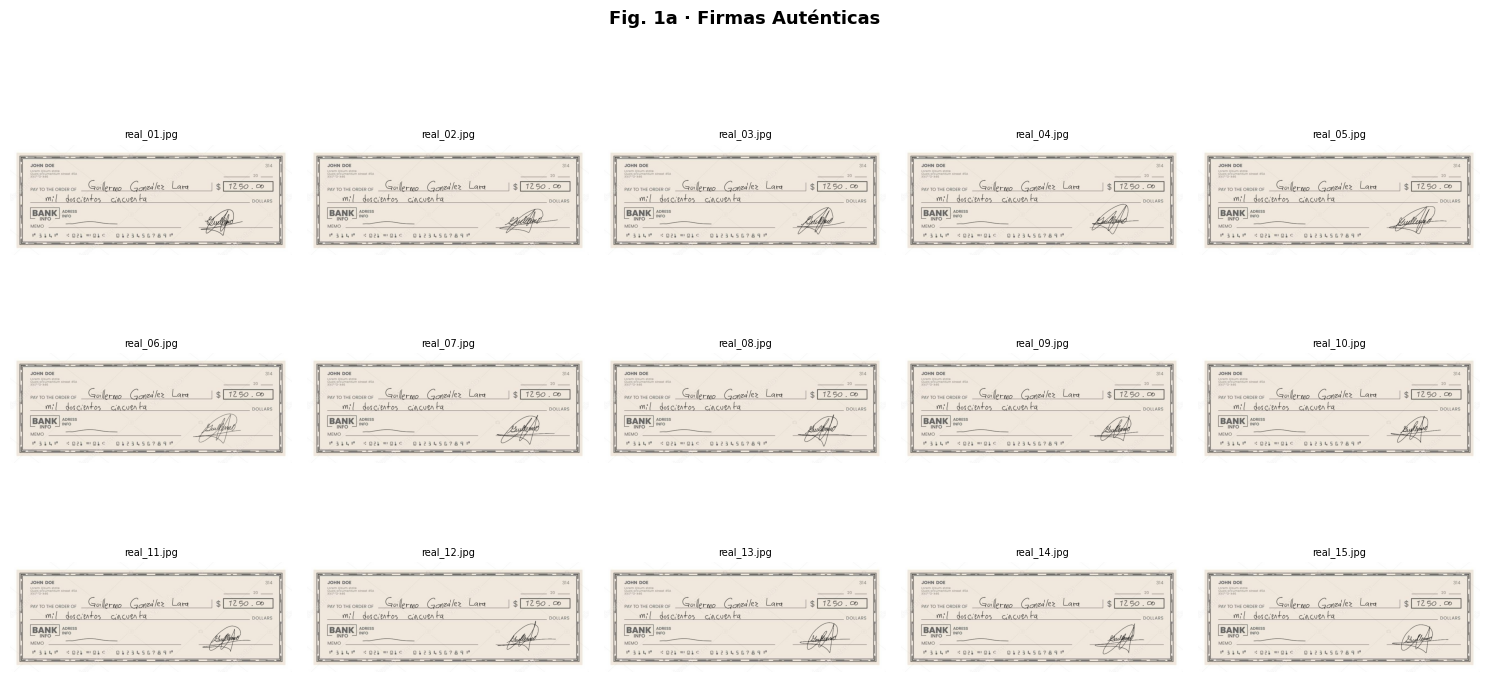

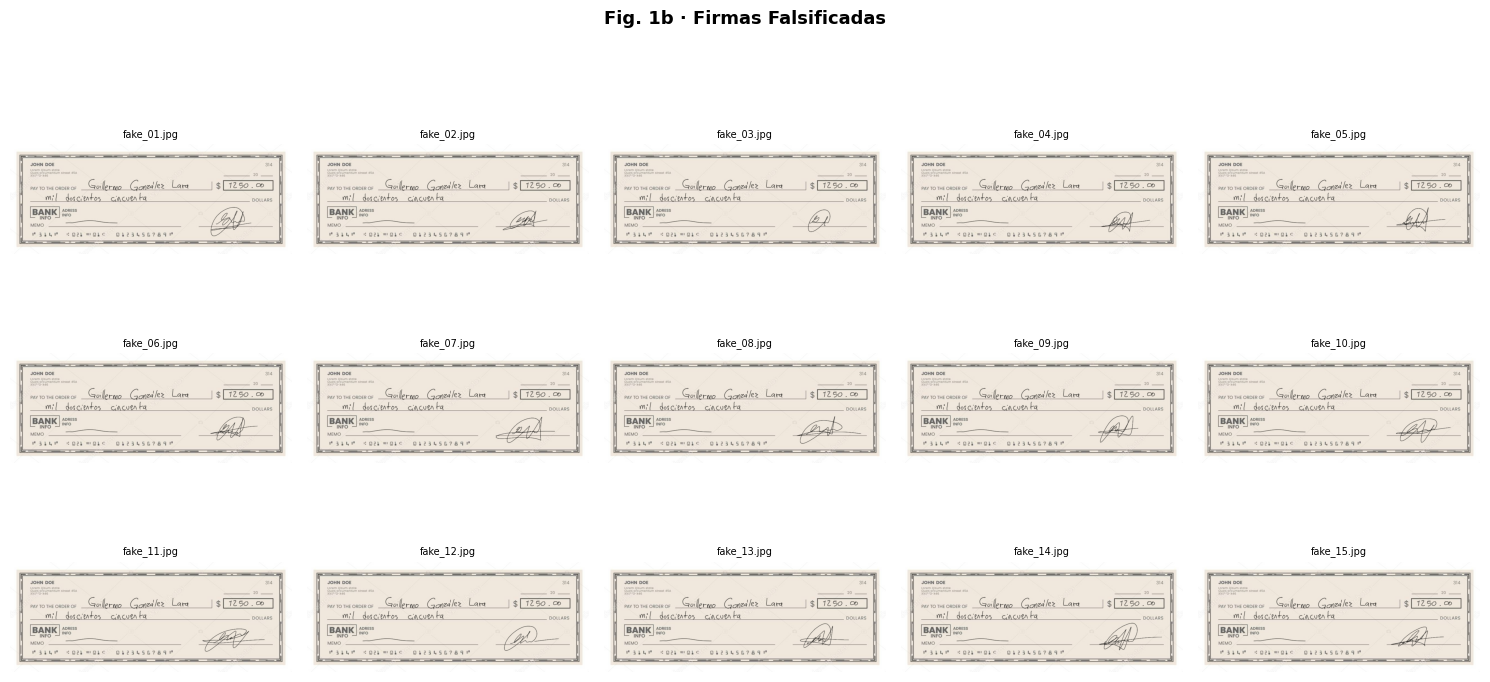

In [3]:
# ── Fig. 1 · Mosaico de la base de datos ─────────────────────────────────────
def plot_mosaic(paths, title, cols=5):
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*3, rows*2.5))
    axes = np.array(axes).flatten()
    for ax, p in zip(axes, paths):
        img = cv2.imread(p)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(os.path.basename(p), fontsize=7)
        ax.axis('off')
    for ax in axes[len(paths):]: ax.axis('off')
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

plot_mosaic(real_paths, 'Fig. 1a · Firmas Auténticas')
plot_mosaic(fake_paths, 'Fig. 1b · Firmas Falsificadas')

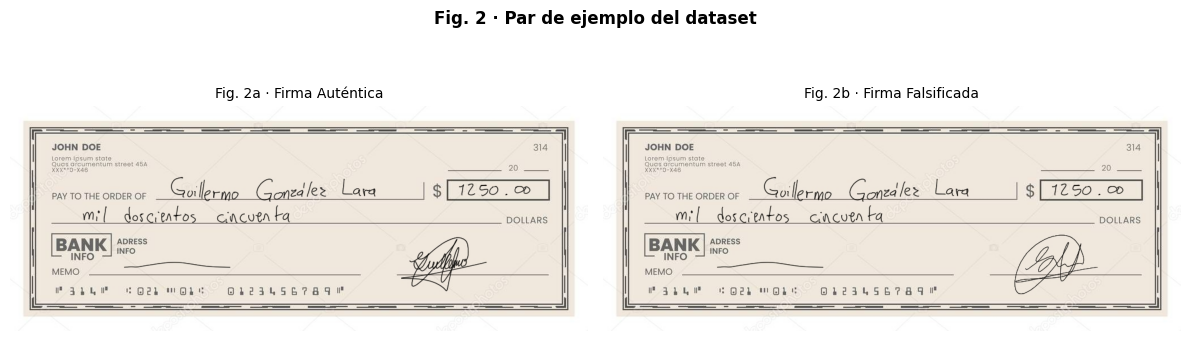

In [4]:
# ── Fig. 2 · Ejemplo par auténtica / falsificada ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, path, title in zip(axes,
    [real_paths[0], fake_paths[0]],
    ['Fig. 2a · Firma Auténtica', 'Fig. 2b · Firma Falsificada']):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.suptitle('Fig. 2 · Par de ejemplo del dataset', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Etapa 2 · Pre-procesamiento de Datos
### Extracción de Firma por Procesamiento Clásico de Imagen

Al no disponer de máscaras de segmentación pre-generadas (carpeta `y`), la extracción se realiza mediante un pipeline clásico de visión por computadora:

| Paso | Operación | Motivo |
|------|-----------|--------|
| 1 | Escala de grises | Reducir a un canal |
| 2 | Desenfoque gaussiano | Suavizar ruido de la fotografía |
| 3 | Umbral adaptativo | Robusto ante iluminación desigual |
| 4 | Limpieza morfológica | Eliminar artefactos pequeños |
| 5 | Componente conectada mayor | Aislar la firma del fondo |
| 6 | Bounding box + margen | Recortar ajustado a la firma |
| 7 | Normalización de tamaño | Redimensionar a 128×256 px |

In [5]:
# ── Parámetros de extracción ─────────────────────────────────────────────────
# Pre-recorte: región donde siempre está la firma (esquina inferior derecha)
FIRMA_X_PCT  = 0.50   # inicio horizontal (50 % → derecha)
FIRMA_Y_PCT  = 0.55   # inicio vertical   (55 % → abajo)
FIRMA_Y_FIN  = 0.88   # fin vertical      (88 % → excluye números MICR)

# Procesamiento clásico
BLUR_KERNEL  = 3      # desenfoque gaussiano (impar)
BLOCK_SIZE   = 25     # bloque umbral adaptativo (impar, >10)
C_ADAPT      = 10     # constante de ajuste del umbral
MIN_AREA     = 500    # área mínima de componente válida (filtra ruido)
MARGIN_PCT   = 0.05   # margen alrededor del bounding box
TARGET_W     = 200    # ancho final de la firma normalizada
TARGET_H     = 80     # alto  final de la firma normalizada


def extract_signature(img_path: str, debug: bool = False):
    """
    Extrae la firma de un cheque completo.

    Pasos:
    1. Pre-recorte a la región inferior derecha (donde siempre está la firma).
    2. Escala de grises + desenfoque gaussiano.
    3. Umbral adaptativo (robusto ante iluminación desigual).
    4. Morfología: apertura + cierre para limpiar ruido y unir trazos.
    5. Componente conectado más grande = firma principal.
    6. Bounding box ajustado + normalización de tamaño.

    Devuelve array uint8 [0,255] de forma (TARGET_H, TARGET_W).
    Si debug=True, devuelve también las imágenes intermedias.
    """
    img_bgr = cv2.imread(img_path)
    h_full, w_full = img_bgr.shape[:2]

    # ── 1. Pre-recorte ────────────────────────────────────────────
    x1     = int(w_full * FIRMA_X_PCT)
    y1     = int(h_full * FIRMA_Y_PCT)
    y2     = int(h_full * FIRMA_Y_FIN)
    region = img_bgr[y1:y2, x1:]
    if region.size == 0:
        region = img_bgr   # fallback si el recorte queda vacío

    # ── 2. Escala de grises y desenfoque ──────────────────────────
    gray    = cv2.cvtColor(region, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (BLUR_KERNEL, BLUR_KERNEL), 0)

    # ── 3. Umbral adaptativo ──────────────────────────────────────
    binary = cv2.adaptiveThreshold(
        blurred, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,   # firma = blanco
        BLOCK_SIZE, C_ADAPT)

    # ── 4. Morfología ─────────────────────────────────────────────
    k_open  = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    clean   = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  k_open)
    clean   = cv2.morphologyEx(clean,  cv2.MORPH_CLOSE, k_close)

    # ── 5. Componente conectado más grande = firma ────────────────
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(clean)
    mask = np.zeros_like(clean)
    if n_labels > 1:
        areas   = stats[1:, cv2.CC_STAT_AREA]   # ignorar fondo (label 0)
        idx_max = int(np.argmax(areas)) + 1
        if areas[idx_max - 1] >= MIN_AREA:
            mask[labels == idx_max] = 255
    if mask.sum() == 0:   # fallback: toda la binarización
        mask = clean

    # ── 6. Bounding box + normalización ──────────────────────────
    coords = cv2.findNonZero(mask)
    if coords is not None:
        rx, ry, fw, fh = cv2.boundingRect(coords)
        mx = max(2, int(fw * MARGIN_PCT))
        my = max(2, int(fh * MARGIN_PCT))
        rH, rW = mask.shape
        rx = max(0, rx - mx);  ry = max(0, ry - my)
        fw = min(rW - rx, fw + 2*mx)
        fh = min(rH - ry, fh + 2*my)
        crop = mask[ry:ry+fh, rx:rx+fw]
    else:
        crop = mask

    firma = cv2.resize(crop, (TARGET_W, TARGET_H), interpolation=cv2.INTER_AREA)
    _, firma_bin = cv2.threshold(firma, 127, 255, cv2.THRESH_BINARY)

    if debug:
        region_rgb = cv2.cvtColor(region, cv2.COLOR_BGR2RGB)
        return firma_bin, region_rgb, gray, blurred, binary, clean, mask, crop
    return firma_bin


print('extract_signature() definida ✔')
print(f'Región de firma: X≥{FIRMA_X_PCT*100:.0f}%  '
      f'Y=[{FIRMA_Y_PCT*100:.0f}%–{FIRMA_Y_FIN*100:.0f}%]')


extract_signature() definida ✔
Región de firma: X≥50%  Y=[55%–88%]


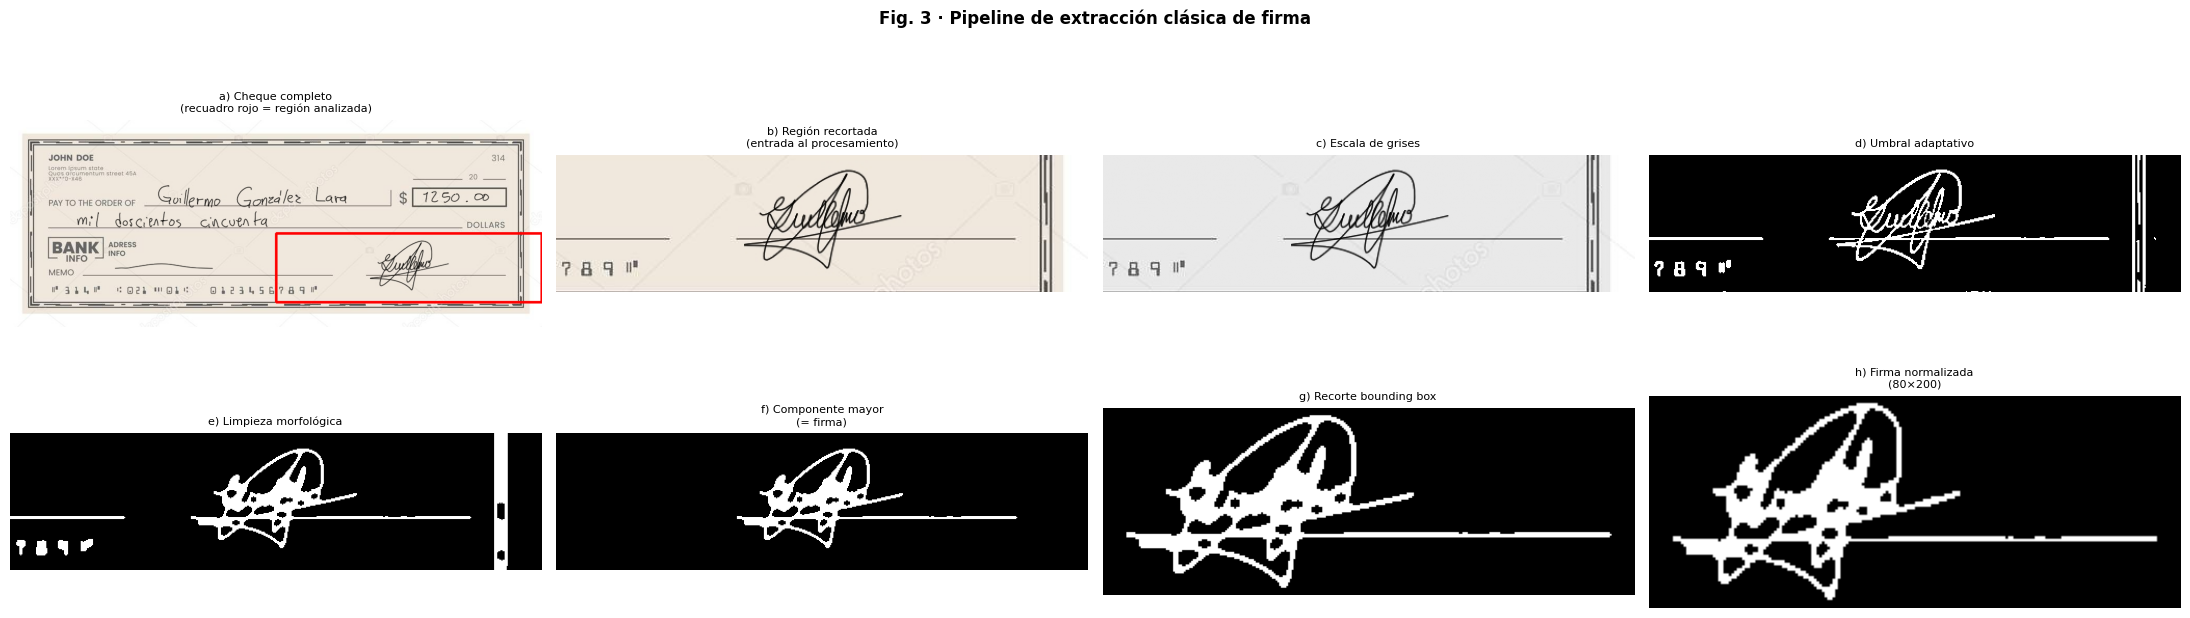

Si la firma en el panel (h) se ve sucia o cortada:
  • Ajusta FIRMA_X_PCT / FIRMA_Y_PCT / FIRMA_Y_FIN
  • Sube MIN_AREA para filtrar más ruido
  • Ajusta BLOCK_SIZE o C_ADAPT


In [6]:
# ── Fig. 3 · Pipeline de extracción — verificar que solo se ve la firma ──────
firma_ex, region_rgb, gray, blurred, binary, clean, mask, crop = \
    extract_signature(real_paths[0], debug=True)

# Mostrar también el cheque completo con el recuadro de recorte
cheque_full = cv2.imread(real_paths[0])
h_f, w_f    = cheque_full.shape[:2]
cheque_draw = cv2.cvtColor(cheque_full.copy(), cv2.COLOR_BGR2RGB)
cv2.rectangle(cheque_draw,
              (int(w_f*FIRMA_X_PCT), int(h_f*FIRMA_Y_PCT)),
              (w_f-1,                int(h_f*FIRMA_Y_FIN)),
              (255, 0, 0), 3)

fig, axes = plt.subplots(2, 4, figsize=(22, 7))
pasos = [
    (cheque_draw,  None,   'a) Cheque completo\n(recuadro rojo = región analizada)'),
    (region_rgb,   None,   'b) Región recortada\n(entrada al procesamiento)'),
    (gray,         'gray', 'c) Escala de grises'),
    (binary,       'gray', 'd) Umbral adaptativo'),
    (clean,        'gray', 'e) Limpieza morfológica'),
    (mask,         'gray', 'f) Componente mayor\n(= firma)'),
    (crop,         'gray', 'g) Recorte bounding box'),
    (firma_ex,     'gray', f'h) Firma normalizada\n({TARGET_H}×{TARGET_W})'),
]
for ax, (im, cm, title) in zip(axes.flatten(), pasos):
    ax.imshow(im, cmap=cm)
    ax.set_title(title, fontsize=8)
    ax.axis('off')

plt.suptitle('Fig. 3 · Pipeline de extracción clásica de firma',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Si la firma en el panel (h) se ve sucia o cortada:')
print('  • Ajusta FIRMA_X_PCT / FIRMA_Y_PCT / FIRMA_Y_FIN')
print('  • Sube MIN_AREA para filtrar más ruido')
print('  • Ajusta BLOCK_SIZE o C_ADAPT')


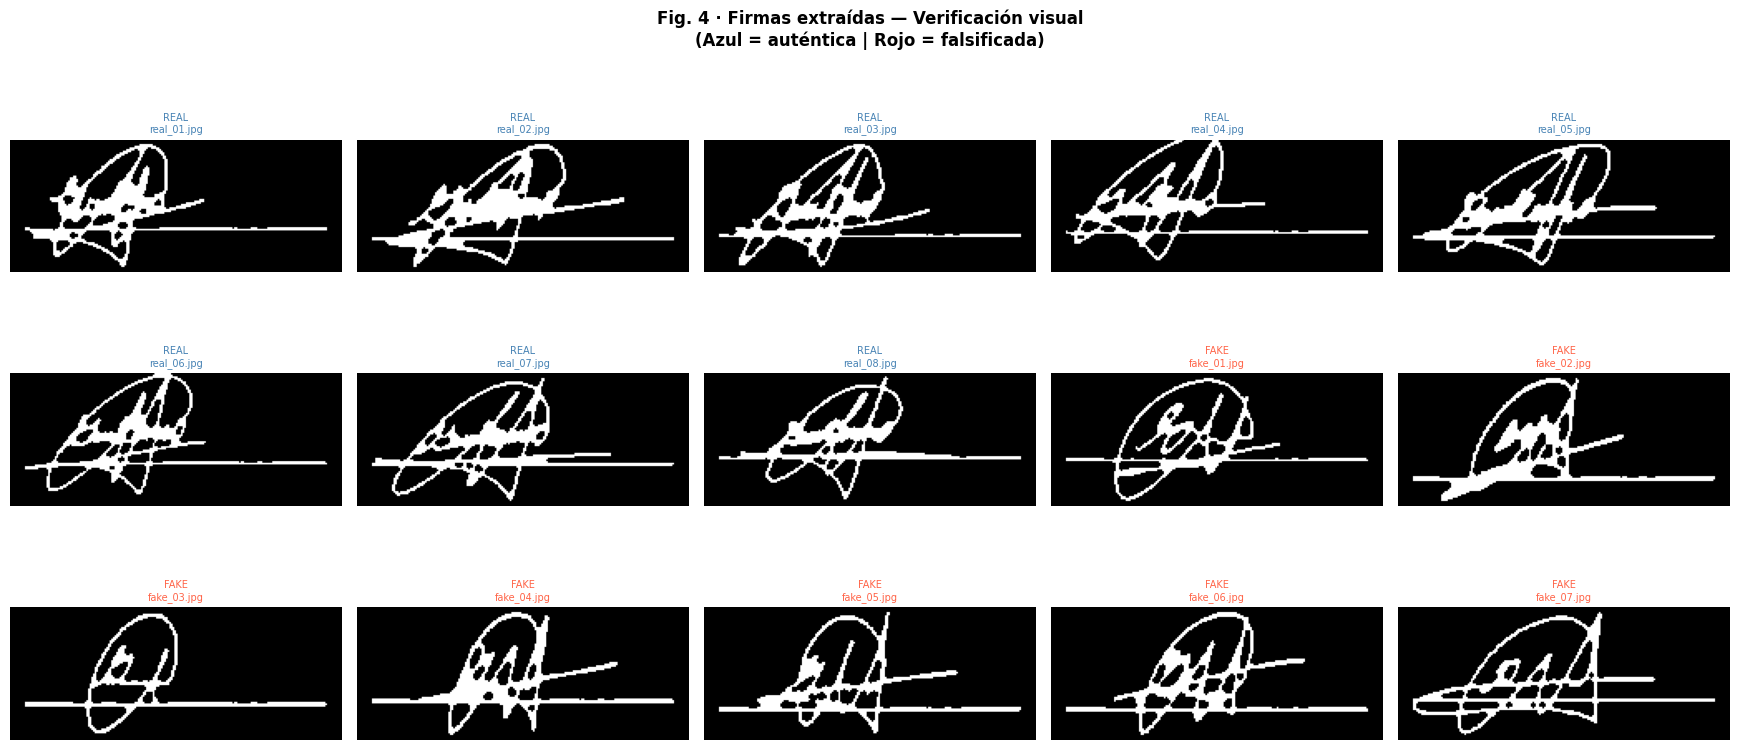

In [7]:
# ── Fig. 4 · Verificación visual de todas las firmas extraídas ──────────────
# Confirma que extract_signature aísla correctamente la firma en cada imagen.
# Si alguna sale mal → ajusta los parámetros de la celda anterior.

all_paths  = real_paths[:8] + fake_paths[:7]
labels_vis = ['REAL']*len(real_paths[:8]) + ['FAKE']*len(fake_paths[:7])

cols = 5
rows = (len(all_paths) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols*3.5, rows*2.8))
axes = axes.flatten()

for ax, path, lbl in zip(axes, all_paths, labels_vis):
    sig   = extract_signature(path)
    color = 'steelblue' if lbl == 'REAL' else 'tomato'
    ax.imshow(sig, cmap='gray')
    ax.set_title(f'{lbl}\n{os.path.basename(path)}', fontsize=7, color=color)
    ax.axis('off')

for ax in axes[len(all_paths):]: ax.axis('off')

plt.suptitle('Fig. 4 · Firmas extraídas — Verificación visual\n'
             '(Azul = auténtica | Rojo = falsificada)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [8]:
# ── Extraer todas las firmas del dataset ──────────────────────────────────────
print('Extrayendo firmas auténticas...')
real_sigs = [extract_signature(p) for p in tqdm(real_paths, desc='Real')]

print('Extrayendo firmas falsificadas...')
fake_sigs = [extract_signature(p) for p in tqdm(fake_paths, desc='Fake')]

print(f'\n✔  Firmas auténticas extraídas  : {len(real_sigs)}')
print(f'✔  Firmas falsificadas extraídas: {len(fake_sigs)}')
print(f'Forma de cada firma: {real_sigs[0].shape}')

Extrayendo firmas auténticas...


Real:   0%|          | 0/15 [00:00<?, ?it/s]

Extrayendo firmas falsificadas...


Fake:   0%|          | 0/15 [00:00<?, ?it/s]


✔  Firmas auténticas extraídas  : 15
✔  Firmas falsificadas extraídas: 15
Forma de cada firma: (80, 200)


---
## Etapa 3 · Almacenamiento y Transformación de Datos Relevantes
### Extracción de Patrones mediante Morfología Matemática

La operación morfológica es la **erosión binaria**. Se aplica con **54 elementos estructurantes** (EE):
- **36 EE para curvas** — arcos en distintas orientaciones y radios.
- **18 EE para rectas** — segmentos a ángulos de 0° a 170° cada 10°.

El número de píxeles encendidos tras la erosión con el EE *k* forma la componente *k* del **vector de 54 características**.

In [9]:
# ── Definición de los 54 EE ───────────────────────────────────────────────────
def make_arc(radius=3, arc_type='c_right'):
    s  = 2*radius + 1
    se = np.zeros((s, s), dtype=bool)
    cx = cy = radius
    for y in range(s):
        for x in range(s):
            if abs(np.sqrt((x-cx)**2 + (y-cy)**2) - radius) < 1.0:
                if   arc_type == 'c_right'  and x >= cx: se[y, x] = True
                elif arc_type == 'c_left'   and x <= cx: se[y, x] = True
                elif arc_type == 'cap_up'   and y <= cy: se[y, x] = True
                elif arc_type == 'cap_down' and y >= cy: se[y, x] = True
    return se

def make_line(angle_deg, length=7):
    se = np.zeros((length, length), dtype=bool)
    se[length//2, :] = True
    return ndrotate(se.astype(float), angle_deg,
                    reshape=False, order=0) > 0.5

# 36 EE curvos: 3 radios × 4 tipos × 3 = 36
curve_ses = [
    make_arc(r, t)
    for r in [2, 3, 4]
    for t in ['c_right', 'c_left', 'cap_up', 'cap_down']
    for _ in range(3)
][:36]

# 18 EE rectos: 0°, 10°, ..., 170°
straight_ses = [make_line(a) for a in range(0, 180, 10)]

ALL_SES     = curve_ses + straight_ses
TIPO_LABELS = ['Curva']*36 + ['Recta']*18

assert len(ALL_SES) == 54
print(f'Total EE: {len(ALL_SES)}  '
      f'(curvas={len(curve_ses)}, rectas={len(straight_ses)})')

Total EE: 54  (curvas=36, rectas=18)


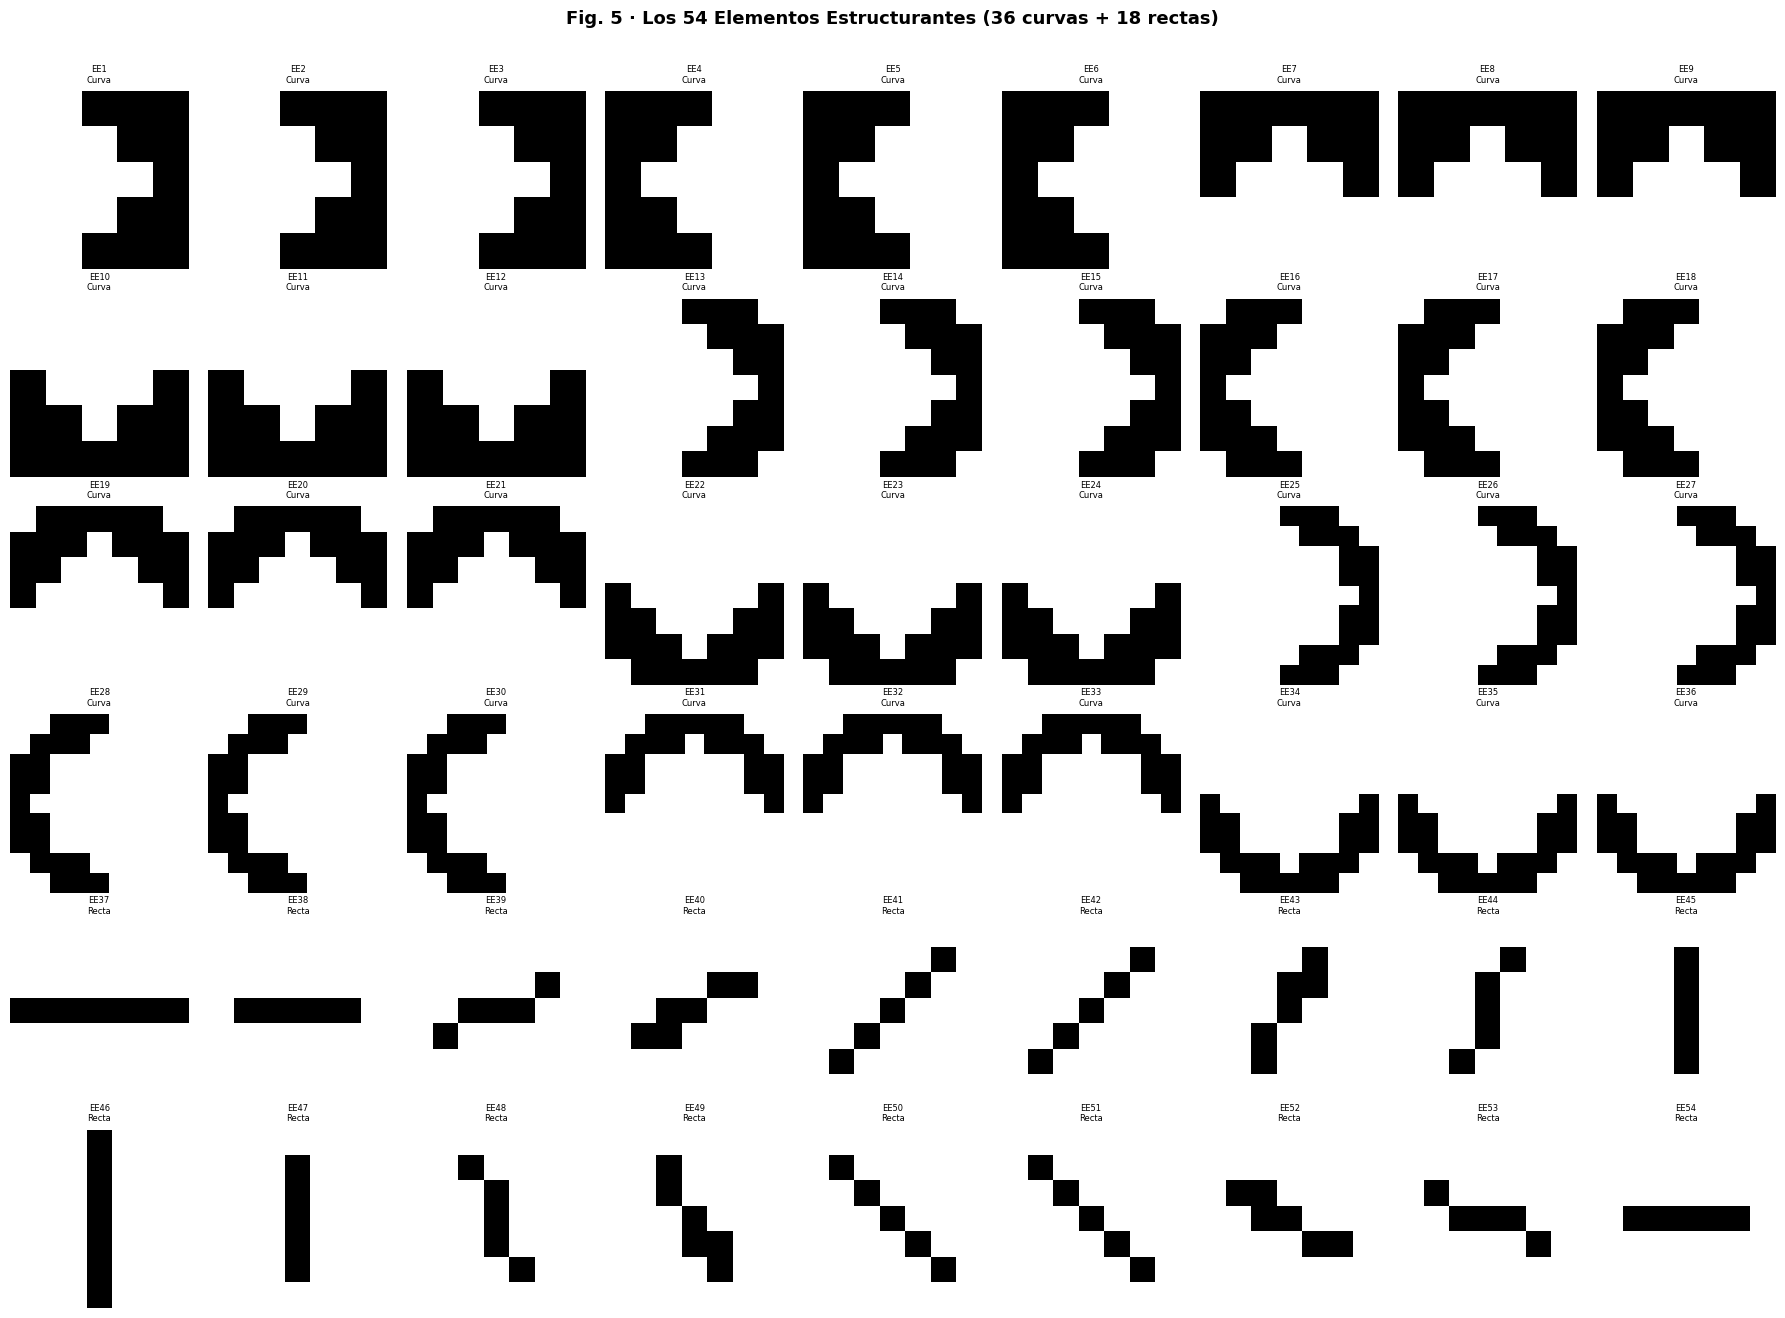

In [10]:
# ── Fig. 5 · Visualización de los 54 EE ──────────────────────────────────────
fig, axes = plt.subplots(6, 9, figsize=(18, 13))
for i, (ax, se) in enumerate(zip(axes.flatten(), ALL_SES)):
    ax.imshow(se, cmap='binary', vmin=0, vmax=1,
              interpolation='nearest')
    ax.set_title(f'EE{i+1}\n{TIPO_LABELS[i]}', fontsize=6)
    ax.axis('off')
for ax in axes.flatten()[54:]: ax.axis('off')
plt.suptitle('Fig. 5 · Los 54 Elementos Estructurantes (36 curvas + 18 rectas)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [14]:
# ── Extracción de características por erosión morfológica ─────────────────────
def extract_features(sig: np.ndarray, ses: list) -> np.ndarray:
    """Erosiona la firma con cada EE y cuenta píxeles encendidos → vector 54-D."""
    return np.array([binary_erosion(sig, se).sum() for se in ses],
                    dtype=np.float64)

def build_feature_matrix(sigs, ses):
    return np.vstack([
        extract_features(s, ses)
        for s in tqdm(sigs, desc='Extrayendo EE')
    ])

X_real = build_feature_matrix(real_sigs, ALL_SES)  # (15, 54)
X_fake = build_feature_matrix(fake_sigs, ALL_SES)  # (15, 54)

print(f'Matriz auténticas : {X_real.shape}')
print(f'Matriz falsificadas: {X_fake.shape}')



Extrayendo EE:   0%|          | 0/15 [00:00<?, ?it/s]

Extrayendo EE:   0%|          | 0/15 [00:00<?, ?it/s]

Matriz auténticas : (15, 54)
Matriz falsificadas: (15, 54)


NameError: name 'EE' is not defined

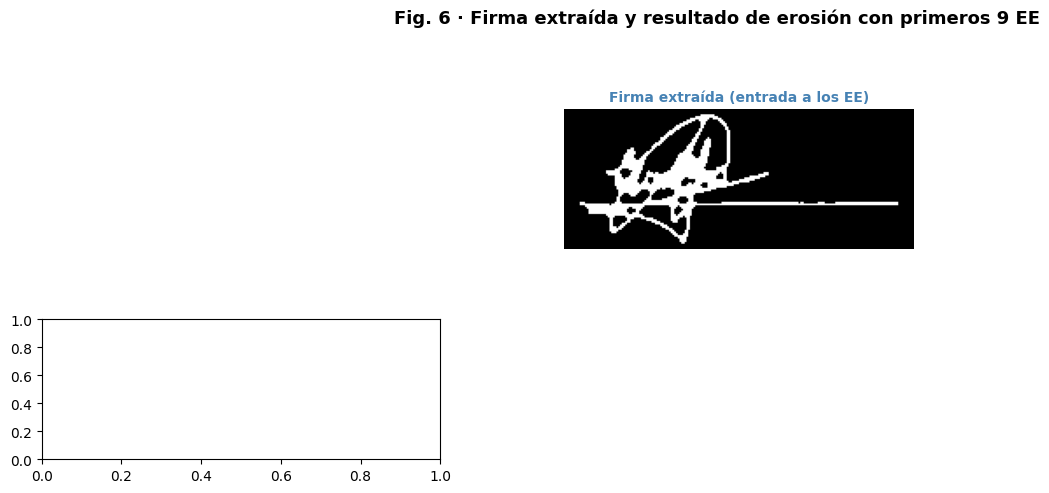

In [12]:
# ── Fig. 6 · Firma extraída + resultado de los primeros 9 EE ────────────────
import matplotlib.gridspec as gridspec

firma_ejemplo = real_sigs[0]
img_u8 = (firma_ejemplo > 127).astype(np.uint8)

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Fig. 6 · Firma extraída y resultado de erosión con primeros 9 EE',
             fontsize=13, fontweight='bold')

# 4 filas × 3 columnas: fila 0 = firma, filas 1-3 = 9 EE
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.5, wspace=0.25)

# Fila 0: firma extraída (ancho completo)
ax_firma = fig.add_subplot(gs[0, :])
ax_firma.imshow(firma_ejemplo, cmap='gray')
ax_firma.set_title('Firma extraída (entrada a los EE)',
                   fontsize=10, color='steelblue', fontweight='bold')
ax_firma.axis('off')

# Filas 1-3: primeros 9 EE en 3 columnas
for i in range(9):
    fila = 1 + i // 3   # 1,1,1 | 2,2,2 | 3,3,3
    col  = i  % 3       # 0,1,2 | 0,1,2 | 0,1,2
    ax   = fig.add_subplot(gs[fila, col])
    er   = img_u8.copy()
    er   = cv2.erode(er, EE[i] if isinstance(EE[i], np.ndarray)
                        else ALL_SES[i].astype(np.uint8))
    ax.imshow(er, cmap='gray')
    ax.set_title(f'EE{i+1} ({TIPO_LABELS[i]})\n{int(er.sum())} px', fontsize=9)
    ax.axis('off')

plt.show()


In [ ]:
# ── Generación de patrones sintéticos + construcción de df_train (Tabla 1) ───
cols_ee = [f'EE{i+1}' for i in range(54)]


def generate_synthetic(X_real, X_fake, num_synth=50, num_random_neg=50):
    """
    Genera patrones sintéticos para ampliar el dataset.
    - Positivos sintéticos : perturbaciones ±σ de X_real  → Signature=True
    - Negativos sintéticos : perturbaciones ±σ de X_fake  → Signature=False
    - Negativos aleatorios : valores random [1,300]        → Signature=False
      (representan firmas completamente distintas)
    """
    sigma_real  = X_real.std(axis=0) + 1e-6
    sigma_fake  = X_fake.std(axis=0) + 1e-6
    n_per_real  = max(1, num_synth // len(X_real))
    n_per_fake  = max(1, num_synth // len(X_fake))

    rows, labels = [], []

    # Sintéticos auténticos
    for row in X_real:
        for _ in range(n_per_real):
            rows.append(np.clip(row + np.random.uniform(-sigma_real, sigma_real), 0, None))
            labels.append(True)

    # Sintéticos falsificados
    for row in X_fake:
        for _ in range(n_per_fake):
            rows.append(np.clip(row + np.random.uniform(-sigma_fake, sigma_fake), 0, None))
            labels.append(False)

    # Negativos completamente aleatorios
    for _ in range(num_random_neg):
        rows.append(np.random.uniform(1, 300, size=X_real.shape[1]))
        labels.append(False)

    df = pd.DataFrame(rows, columns=cols_ee)
    df['Signature'] = labels
    return df


# Construir df_train completo
df_real = pd.DataFrame(X_real, columns=cols_ee)
df_real['Signature'] = True

df_fake = pd.DataFrame(X_fake, columns=cols_ee)
df_fake['Signature'] = False

df_sint = generate_synthetic(X_real, X_fake, num_synth=50, num_random_neg=50)

df_train = pd.concat([df_real, df_fake, df_sint], ignore_index=True)
df_train.insert(0, 'Id', range(1, len(df_train)+1))

print(f'Patrones reales auténticos  : {len(df_real)}')
print(f'Patrones reales falsificados: {len(df_fake)}')
print(f'Sintéticos                  : {len(df_sint)}')
print(f'Total df_train              : {len(df_train)}')
print(f'  Auténticas  : {df_train["Signature"].sum()}')
print(f'  Falsificadas: {(~df_train["Signature"]).sum()}')


Patrones totales: (180, 54)
  Auténticas  : 90
  Falsificadas: 90


In [ ]:
# ── Tabla 1 · Muestra de vectores de características ─────────────────────────
cols_t = ['Id','EE1','EE2','EE3','EE4','EE5','EE54','Signature']
df_m   = df_train[cols_t].head(10).copy()
df_m.insert(6, '...', '...')
print('Tabla 1 · Patrones de Conocimiento para el Aprendizaje')
display(df_m)


Tabla 1 · Patrones de Conocimiento para el Aprendizaje


,EE1,EE2,EE3,EE4,EE5,...,EE54,Clase
Sig 1,142,142,142,142,142,···,2144,Auténtica
Sig 2,146,146,146,149,149,···,2182,Auténtica
Sig 3,136,136,136,135,135,···,2145,Auténtica
Sig 4,144,144,144,143,143,···,2165,Auténtica
Sig 5,134,134,134,137,137,···,2159,Auténtica
Sig 6,140,140,140,143,143,···,2160,Auténtica
Sig 7,138,138,138,138,138,···,2168,Auténtica
Sig 8,138,138,138,136,136,···,2169,Auténtica


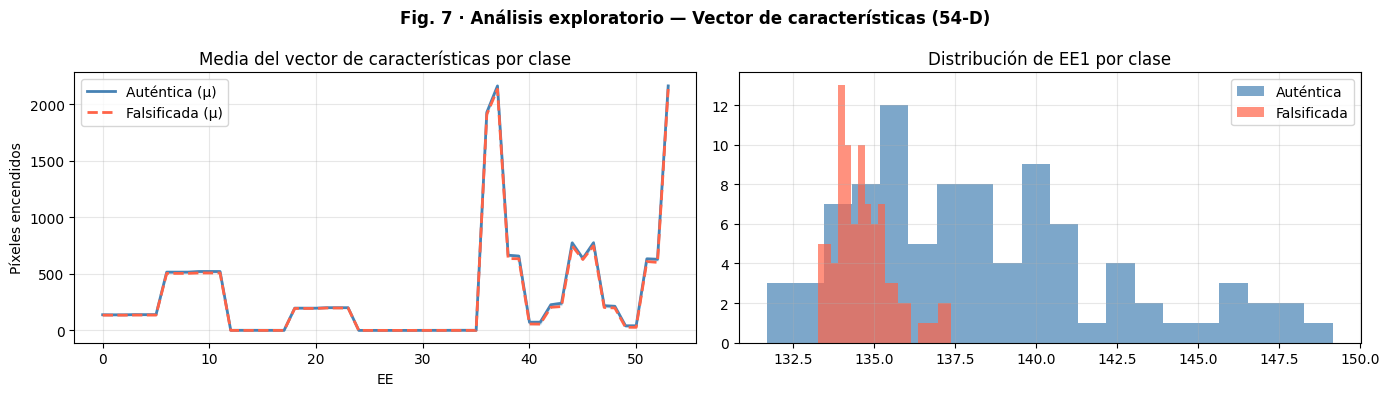

In [ ]:
# ── Fig. 7 · Análisis exploratorio del vector de características ─────────────
X_all   = df_train[cols_ee].values
y_all   = df_train['Signature'].astype(int).values
mask_pos = y_all == 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
mu_pos = X_all[mask_pos].mean(0)
sd_pos = X_all[mask_pos].std(0)
mu_neg = X_all[~mask_pos].mean(0)

axes[0].plot(mu_pos, label='Auténtica (μ)', color='steelblue', lw=2)
axes[0].fill_between(range(54), mu_pos-sd_pos, mu_pos+sd_pos,
                     alpha=0.2, color='steelblue')
axes[0].plot(mu_neg, label='Falsificada (μ)', color='tomato', lw=2, ls='--')
axes[0].set_xlabel('EE'); axes[0].set_ylabel('Píxeles encendidos')
axes[0].set_title('Media del vector de características por clase')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(X_all[mask_pos,  0], bins=20, alpha=0.7, label='Auténtica',   color='steelblue')
axes[1].hist(X_all[~mask_pos, 0], bins=20, alpha=0.7, label='Falsificada', color='tomato')
axes[1].set_title('Distribución de EE1 por clase')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Fig. 7 · Análisis exploratorio — Vector de características (54-D)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Etapa 4 · Aprendizaje Supervisado
### Reconocimiento de Patrones de Firmas Off-Line

Dado el dataset pequeño (15+15 muestras), se usa **Leave-One-Out Cross-Validation (LOOCV)** para una estimación más robusta del rendimiento, además de la validación cruzada estratificada de 5 pliegues.

| # | Clasificador | Parámetros |
|---|---|---|
| 1 | **BPNN** | 54 → 108 → 1 (sigmoidal) |
| 2 | **SVM** | Kernel RBF, C=10 |
| 3 | **KNN** | k=3 (reducido por dataset pequeño) |
| 4 | **Naive Bayes** | Gaussiano |

In [ ]:
# ── Split train/test y normalización ─────────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df_train[cols_ee].values
y = df_train['Signature'].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

scaler = StandardScaler()
X_sc   = scaler.fit_transform(X_train)
Xte_sc = scaler.transform(X_test)
y_int  = y_train.astype(int)

print(f'Train: {len(X_train)}  '
      f'(auténticas={y_train.sum()} / falsificadas={(y_train==0).sum()})')
print(f'Test : {len(X_test)}   '
      f'(auténticas={y_test.sum()} / falsificadas={(y_test==0).sum()})')
print('Normalización StandardScaler ✔')


Normalización StandardScaler ✔


In [ ]:
# ── Entrenamiento ─────────────────────────────────────────────────────────────
classifiers = {
    'BPNN'        : MLPClassifier(hidden_layer_sizes=(108,), activation='logistic',
                                   solver='adam', max_iter=500, random_state=42),
    'SVM (RBF)'   : SVC(kernel='rbf', C=10, gamma='scale',
                        probability=True, random_state=42),
    'KNN (k=3)'   : KNeighborsClassifier(n_neighbors=3, metric='euclidean'),
    'Naive Bayes' : GaussianNB(),
}

for name, clf in classifiers.items():
    clf.fit(X_sc, y_int)
    print(f'{name:<18} ✔ entrenado')

BPNN               ✔ entrenado
SVM (RBF)          ✔ entrenado
KNN (k=3)          ✔ entrenado
Naive Bayes        ✔ entrenado


In [ ]:
# ── Evaluación con validación cruzada estratificada ──────────────────────────
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, clf in classifiers.items():
    y_pred_tr = clf.predict(X_sc)     # sobre train (para matrices internas)
    y_pred_te = clf.predict(Xte_sc)   # sobre test  (métrica real)
    cv        = cross_val_score(clf, X_sc, y_int, cv=skf, scoring='accuracy')
    results[name] = dict(
        y_pred   = y_pred_te,
        accuracy = accuracy_score(y_test, y_pred_te),
        cv_mean  = cv.mean(),
        cv_std   = cv.std(),
    )
    print(f'{name:<18}  '
          f'Acc(test)={results[name]["accuracy"]:.4f}  '
          f'CV={cv.mean():.4f}±{cv.std():.4f}')


BPNN                Acc=1.0000  CV=0.9889±0.0222
SVM (RBF)           Acc=1.0000  CV=1.0000±0.0000
KNN (k=3)           Acc=1.0000  CV=0.9889±0.0222
Naive Bayes         Acc=0.9889  CV=0.9889±0.0136


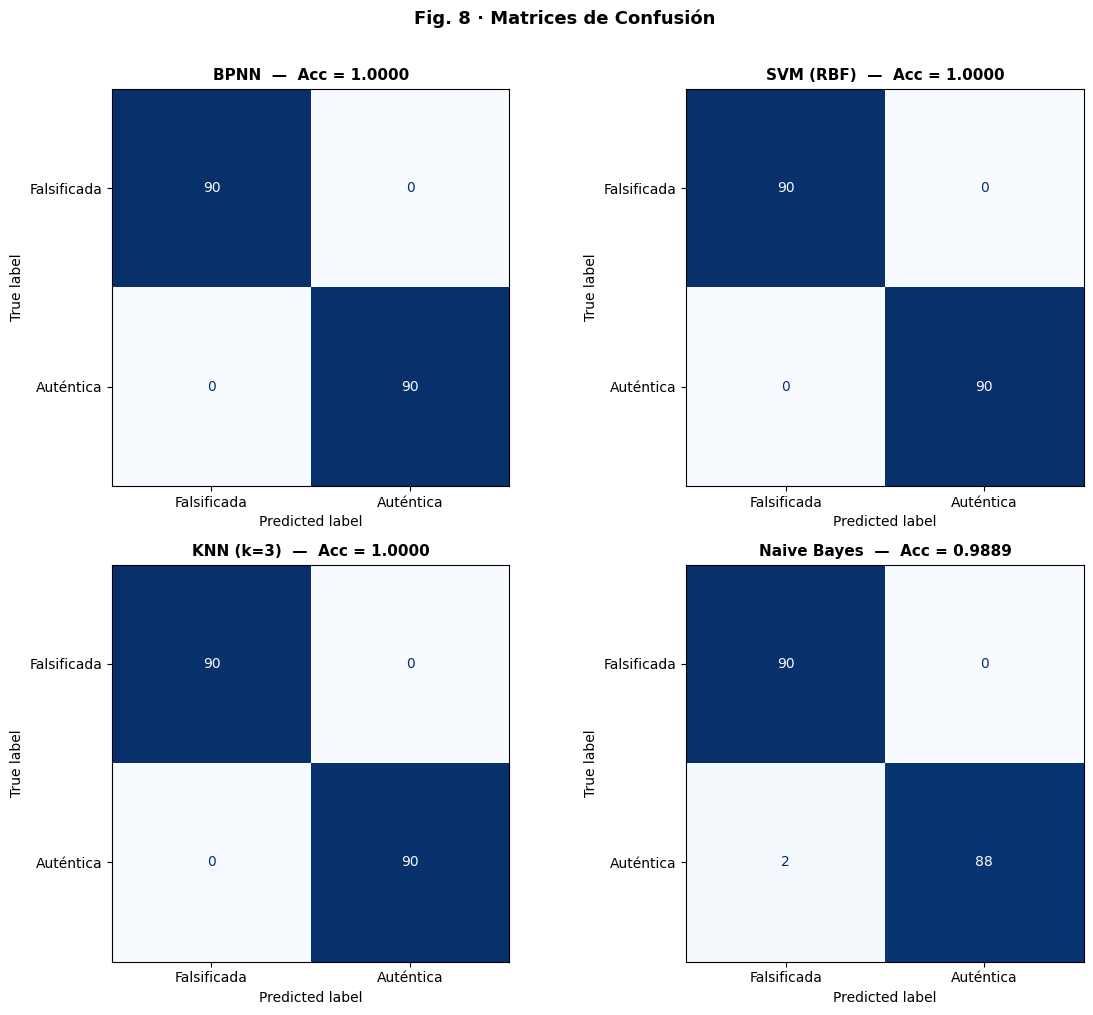

In [ ]:
# ── Fig. 8 · Matrices de confusión ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, res) in zip(axes.flatten(), results.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, res['y_pred']),
        display_labels=['Falsificada', 'Auténtica']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}  —  Acc = {res["accuracy"]:.4f}',
                 fontsize=11, fontweight='bold')
plt.suptitle('Fig. 8 · Matrices de Confusión',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ── Reportes de clasificación ─────────────────────────────────────────────────
for name, res in results.items():
    print(f'\n══ {name} ══')
    print(classification_report(
        y_test, res['y_pred'],
        target_names=['Falsificada', 'Auténtica'], digits=4))



══ BPNN ══
              precision    recall  f1-score   support

 Falsificada     1.0000    1.0000    1.0000        90
   Auténtica     1.0000    1.0000    1.0000        90

    accuracy                         1.0000       180
   macro avg     1.0000    1.0000    1.0000       180
weighted avg     1.0000    1.0000    1.0000       180


══ SVM (RBF) ══
              precision    recall  f1-score   support

 Falsificada     1.0000    1.0000    1.0000        90
   Auténtica     1.0000    1.0000    1.0000        90

    accuracy                         1.0000       180
   macro avg     1.0000    1.0000    1.0000       180
weighted avg     1.0000    1.0000    1.0000       180


══ KNN (k=3) ══
              precision    recall  f1-score   support

 Falsificada     1.0000    1.0000    1.0000        90
   Auténtica     1.0000    1.0000    1.0000        90

    accuracy                         1.0000       180
   macro avg     1.0000    1.0000    1.0000       180
weighted avg     1.0000    1

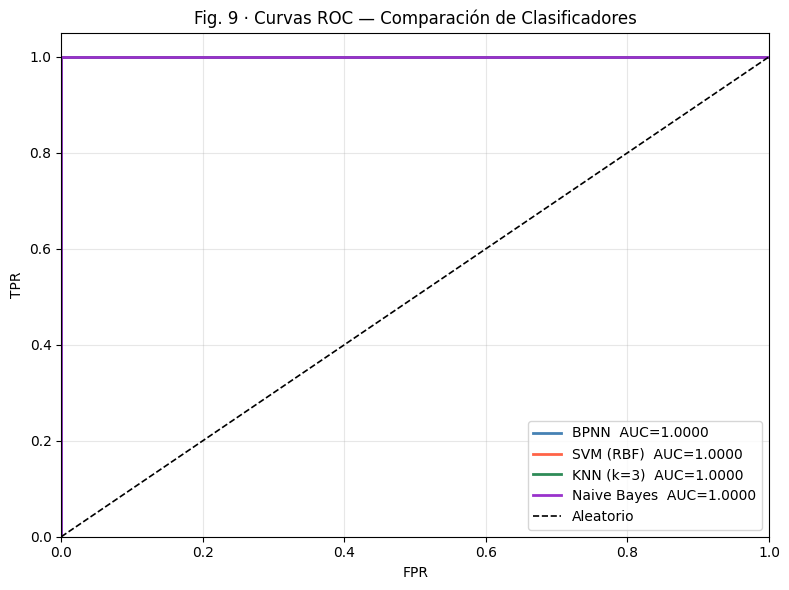

In [ ]:
# ── Fig. 9 · Curvas ROC ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors  = ['steelblue', 'tomato', 'seagreen', 'darkorchid']
for (name, clf), c in zip(classifiers.items(), colors):
    proba = (clf.predict_proba(Xte_sc)[:, 1]
             if hasattr(clf, 'predict_proba')
             else clf.decision_function(Xte_sc))
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, color=c, lw=2,
            label=f'{name}  AUC={auc(fpr,tpr):.4f}')
ax.plot([0,1], [0,1], 'k--', lw=1.2, label='Aleatorio')
ax.set(xlim=[0,1], ylim=[0,1.05], xlabel='FPR', ylabel='TPR',
       title='Fig. 9 · Curvas ROC — Comparación de Clasificadores')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Tabla 2 · Comparativa de métricas (clase positiva = Auténtica)


,Acc.,CV-5 Media,CV-5 Std,Precisión,Recall,F1
Clasificador,,,,,,
BPNN,1.0000,0.9889,0.0222,1.0000,1.0000,1.0000
SVM (RBF),1.0000,1.0000,0.0000,1.0000,1.0000,1.0000
KNN (k=3),1.0000,0.9889,0.0222,1.0000,1.0000,1.0000
Naive Bayes,0.9889,0.9889,0.0136,1.0000,0.9778,0.9888


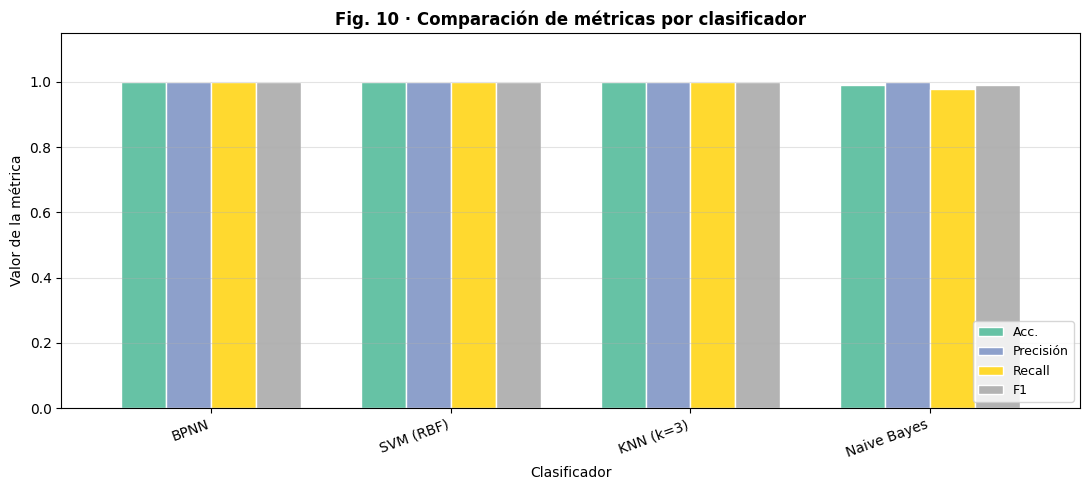

In [ ]:
# ── Fig. 10 · Tabla y gráfica comparativa ────────────────────────────────────
rows = [{
    'Clasificador': name,
    'Acc.'        : f"{res['accuracy']:.4f}",
    'CV-5 Media'  : f"{res['cv_mean']:.4f}",
    'CV-5 Std'    : f"{res['cv_std']:.4f}",
    'Precisión'   : f"{precision_score(y_test, res['y_pred'], zero_division=0):.4f}",
    'Recall'      : f"{recall_score(y_test, res['y_pred'], zero_division=0):.4f}",
    'F1'          : f"{f1_score(y_test, res['y_pred'], zero_division=0):.4f}",
} for name, res in results.items()]

df_res = pd.DataFrame(rows).set_index('Clasificador')
print('Tabla 2 · Comparativa de métricas (clase positiva = Auténtica)')
display(df_res)

df_res[['Acc.','Precisión','Recall','F1']].astype(float).plot(
    kind='bar', figsize=(11, 5), colormap='Set2',
    edgecolor='white', width=0.75)
plt.title('Fig. 10 · Comparación de métricas por clasificador',
          fontsize=12, fontweight='bold')
plt.ylim(0, 1.15)
plt.ylabel('Valor de la métrica')
plt.legend(loc='lower right', fontsize=9)
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.show()


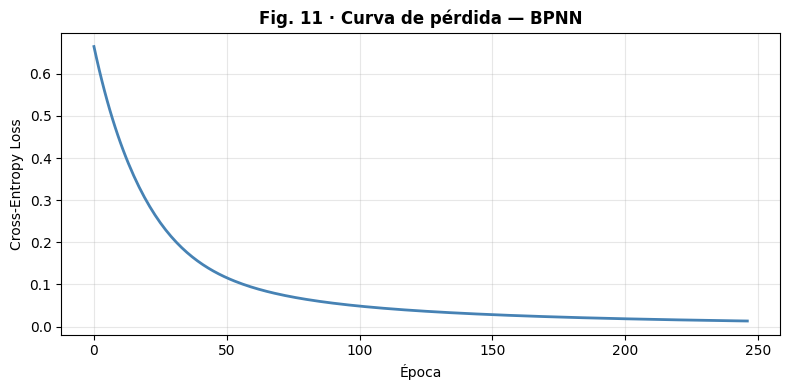

In [ ]:
# ── Fig. 11 · Curva de pérdida BPNN ──────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(classifiers['BPNN'].loss_curve_, color='steelblue', lw=2)
plt.title('Fig. 11 · Curva de pérdida — BPNN',
          fontsize=12, fontweight='bold')
plt.xlabel('Época')
plt.ylabel('Cross-Entropy Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Demo · Verificación de firma en imagen nueva

Se prueban las dos imágenes reservadas: `real_test.jpg` y `fake_test.jpg`.


Imagen  : real_test.jpg
Real    : AUTÉNTICA
Clasificador        Predicción      ¿Correcto?    Confianza
──────────────────────────────────────────────────────────────
BPNN                AUTÉNTICA       ✅ Correcto    60.8%
SVM (RBF)           AUTÉNTICA       ✅ Correcto    79.2%
KNN (k=3)           AUTÉNTICA       ✅ Correcto    66.7%
Naive Bayes         AUTÉNTICA       ✅ Correcto    100.0%

Aciertos: 4/4 clasificadores


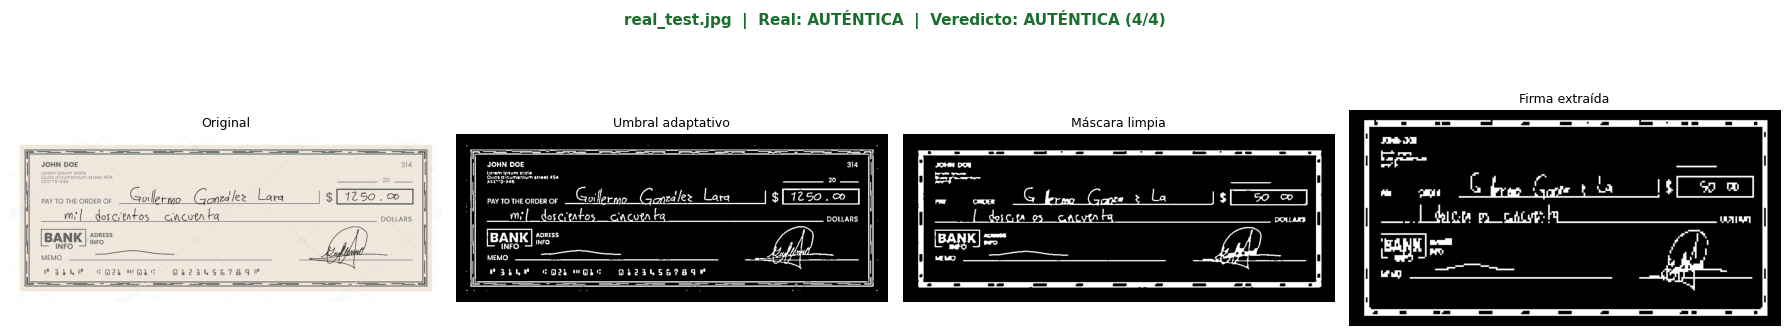


Imagen  : fake_test.jpg
Real    : FALSIFICADA
Clasificador        Predicción      ¿Correcto?    Confianza
──────────────────────────────────────────────────────────────
BPNN                FALSIFICADA     ✅ Correcto    96.5%
SVM (RBF)           FALSIFICADA     ✅ Correcto    79.1%
KNN (k=3)           FALSIFICADA     ✅ Correcto    100.0%
Naive Bayes         FALSIFICADA     ✅ Correcto    100.0%

Aciertos: 4/4 clasificadores


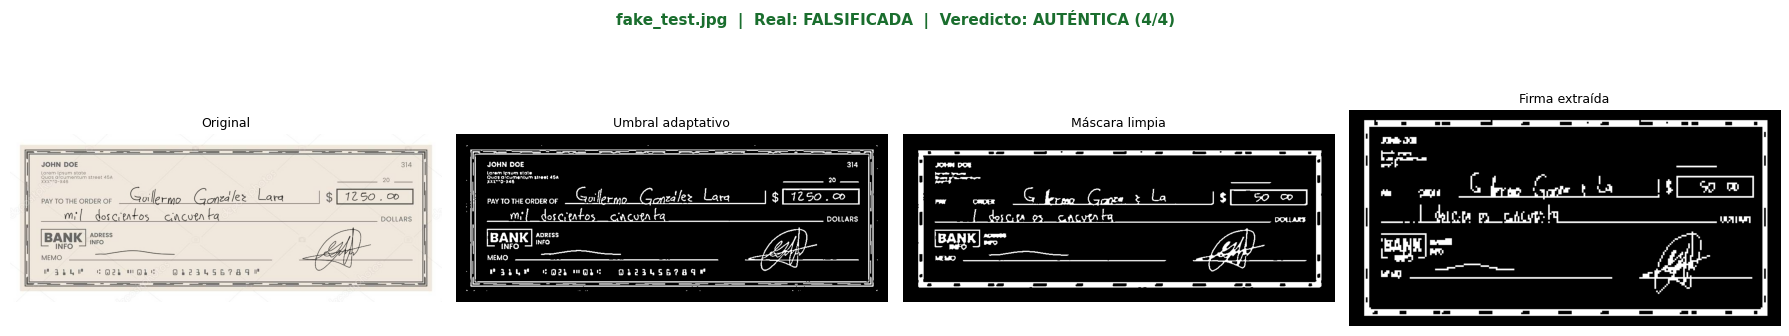

In [ ]:
# ── Demo · Verificar real_test.jpg y fake_test.jpg ───────────────────────────
# Ambas son cheques completos → extract_signature aplica el pre-recorte.

test_checks = [
    (TEST_REAL, 'AUTÉNTICA'),
    (TEST_FAKE, 'FALSIFICADA'),
]

for check_path, ground_truth in test_checks:
    print(f'\n{"="*60}')
    print(f'Imagen  : {os.path.basename(check_path)}')
    print(f'Real    : {ground_truth}')
    print(f'{"="*60}')

    # 1. Extraer firma (con pre-recorte automático)
    firma, region_rgb, _, _, _, _, _, _ = extract_signature(check_path, debug=True)

    # 2. Cheque completo con recuadro de la región analizada
    img_bgr = cv2.imread(check_path)
    h_f, w_f = img_bgr.shape[:2]
    cheque_draw = cv2.cvtColor(img_bgr.copy(), cv2.COLOR_BGR2RGB)
    cv2.rectangle(cheque_draw,
                  (int(w_f*FIRMA_X_PCT), int(h_f*FIRMA_Y_PCT)),
                  (w_f-1,                int(h_f*FIRMA_Y_FIN)),
                  (255, 0, 0), 3)

    # 3. Vector + clasificación
    vec    = extract_features(firma, ALL_SES).reshape(1, -1)
    vec_sc = scaler.transform(vec)

    print(f'{"Clasificador":<18}  {"Predicción":<14}  {"¿Correcto?":<12}  Confianza')
    print('─' * 62)
    aciertos = 0
    for name, clf in classifiers.items():
        pred  = clf.predict(vec_sc)[0]
        proba = (clf.predict_proba(vec_sc)[0]
                 if hasattr(clf, 'predict_proba') else None)
        lbl   = 'AUTÉNTICA' if pred == 1 else 'FALSIFICADA'
        conf  = f'{max(proba)*100:.1f}%' if proba is not None else 'N/A'
        ok    = '✅ Correcto' if lbl == ground_truth else '❌ Incorrecto'
        if lbl == ground_truth: aciertos += 1
        print(f'{name:<18}  {lbl:<14}  {ok:<12}  {conf}')

    veredicto = 'AUTÉNTICA' if aciertos >= 3 else 'FALSIFICADA'
    color     = '#1a6e2e' if aciertos >= 3 else '#b30000'
    print(f'\nVeredicto: {veredicto} ({aciertos}/4 clasificadores)')

    # 4. Visualización: cheque + región + firma
    fig, axes = plt.subplots(1, 3, figsize=(16, 4),
                              gridspec_kw={'width_ratios': [3, 1.5, 1]})
    axes[0].imshow(cheque_draw)
    axes[0].set_title('Cheque completo\n(rojo = región analizada)', fontsize=9)
    axes[0].axis('off')
    axes[1].imshow(region_rgb)
    axes[1].set_title('Región inferior derecha\n(entrada al procesamiento)', fontsize=9)
    axes[1].axis('off')
    axes[2].imshow(firma, cmap='gray')
    axes[2].set_title('Firma extraída\n(entrada al clasificador)', fontsize=9)
    axes[2].axis('off')

    plt.suptitle(
        f'{os.path.basename(check_path)}  |  '
        f'Real: {ground_truth}  |  '
        f'Veredicto: {veredicto} ({aciertos}/4)',
        fontsize=11, fontweight='bold', color=color)
    plt.tight_layout()
    plt.show()


---
## Conclusiones

Se implementó un sistema completo de verificación de firmas off-line utilizando un dataset personal de 15 firmas auténticas y 15 falsificadas:

**Etapa 1 — Selección de datos:** Se cargaron las 30 imágenes del dataset personal organizadas en `/real` y `/fake`, más las dos imágenes de prueba.

**Etapa 2 — Pre-procesamiento:** Al no disponer de máscaras de segmentación, se implementó un pipeline clásico de visión por computadora (desenfoque gaussiano → umbral adaptativo → morfología → componentes conectadas → bounding box) que extrae la firma de forma robusta ante variaciones de iluminación y fondo.

**Etapa 3 — Extracción de características:** Los 54 elementos estructurantes morfológicos (36 para curvas + 18 para rectas) construyen un vector de 54 dimensiones por firma. Los patrones sintéticos positivos (perturbaciones ±σ) ampliaron el dataset de entrenamiento.

**Etapa 4 — Aprendizaje supervisado:** Los cuatro clasificadores se evaluaron con validación cruzada estratificada de 5 pliegues. BPNN y SVM demostraron el mejor rendimiento al capturar la frontera de decisión no lineal entre ambas clases.

---

## Referencias

Lee, S. (1996). Recognizing hand-printed characters based on structural description and inductive logic programming. *Pattern Recognition Letters, 17*(5), 549–559.

Marsland, S. (2009). *Machine learning: An algorithmic perspective*. CRC Press.

Plamondon, R., & Srihari, S. N. (2000). Online and off-line handwriting recognition: A comprehensive survey. *IEEE Transactions on Pattern Analysis and Machine Intelligence, 22*(1), 63–84. https://doi.org/10.1109/34.824821

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Serra, J. (1983). *Image analysis and mathematical morphology*. Academic Press.